# 1. Lobster thermal habitat
### This code calculates the area of lobster thermal habitat at seafloor using GLORYS reanalysis data
### The lobster thermal habitat is defined as the area at the seafloor with temperature less than or equal to 18C as of2025 (previously 20C)
# 2. Cold Pool Volume and Duration
### This code calculates the volume and duration of the cold pool within the NYB using GLORYS reanalysis data
### The cold pool is defined as the volume of water bounded by the 10C isotherm and the 34 psu contour

   
#### *This code was created by L. Gruenburg and last edited on Oct 24 2025
### The glorys reanalysis dataset can be downloaded from copernicus marine services.  I would reccomend you double check this site before these indicators are calculated to see if a more updated data product is available.  The website requires you to create an account and login but it is very quick and easy.

## https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/description

In [131]:
import xarray as xr
import geopandas as gpd
import regionmask
import numpy as np
import pandas as pn
import matplotlib.pyplot as plt
%matplotlib inline
import math

In [5]:
gl1 = xr.open_dataset('~/Desktop/NYB_Indicators_Calculations/CalculateIndicators/WaterTemperature/data/glorysBT_1993_2021.nc')

In [6]:
gl2 = xr.open_dataset('~/Desktop/NYB_Indicators_Calculations/CalculateIndicators/WaterTemperature/data/glorysBT_2021_2025.nc')

In [8]:
glorysBT = xr.concat([gl1,gl2], dim = 'time')

In [18]:
glorysBT

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 11925, latitude: 109, longitude: 133)
Coordinates:
  * latitude   (latitude) float32 436B 35.0 35.08 35.17 ... 43.83 43.92 44.0
  * longitude  (longitude) float32 532B -76.0 -75.92 -75.83 ... -65.08 -65.0
  * time       (time) datetime64[ns] 95kB 1993-01-01 1993-01-02 ... 2025-08-25
Data variables:
    bottomT    (time, latitude, longitude) float64 1GB 18.91 19.54 ... nan nan
Attributes:
    comment:                   CMEMS product
    references:                http://www.mercator-ocean.fr
    Conventions:               CF-1.4
    institution:               MERCATOR OCEAN
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    copernicusmarine_version:  2.2.2

In [14]:
# Load NYB shapefile
NYB = gpd.read_file('~/Desktop/NYB_Indicators_Calculations/Datasets/Shapefiles/PlanningArea_NYocean_NYSDOS.shp')

In [15]:
# Alter the projection to WGS84 see https://epsg.io/4326
NYB = NYB.to_crs(epsg=4326)

In [16]:
# function for cropping the data to the shape
def crop_nd(data, longitude_name, latitude_name, shape):
    
    # Get the region of interest
    region = regionmask.from_geopandas(shape)
    
    # Create the mask
    mask = region.mask(data[longitude_name].astype('f4'), data[latitude_name].astype('f4'))
    
    # Apply mask to the data
    masked_ds = data.where(mask == region.numbers[0])
    
    return masked_ds 

In [21]:
glorysBTnyb = crop_nd(glorysBT, 'longitude', 'latitude', NYB)

In [25]:
glorysBTnybM = glorysBTnyb.resample(time ='MS').mean()

In [26]:
glorysBTnybM

<xarray.Dataset> Size: 45MB
Dimensions:    (time: 392, latitude: 109, longitude: 133)
Coordinates:
  * latitude   (latitude) float32 436B 35.0 35.08 35.17 ... 43.83 43.92 44.0
  * longitude  (longitude) float32 532B -76.0 -75.92 -75.83 ... -65.08 -65.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-08-01
Data variables:
    bottomT    (time, latitude, longitude) float64 45MB nan nan nan ... nan nan
Attributes:
    comment:                   CMEMS product
    references:                http://www.mercator-ocean.fr
    Conventions:               CF-1.4
    institution:               MERCATOR OCEAN
    title:                     daily mean fields from Global Ocean Physics An...
    source:                    MERCATOR GLORYS12V1
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    copernicusmarine_version:  2.2.2

In [32]:
(glorysBTnybM.bottomT <=18).sum()

<xarray.DataArray 'bottomT' ()> Size: 8B
array(256313)

In [38]:
# Loop through each month and calculate the area at each time step
pctgrdcell = np.empty(392) # update here for adding another year of data
pctgrdcell[:] = np.nan
for i in range(392):
    pctgrdcell[i] = (glorysBTnybM.bottomT[i,:,:] >=18).sum()

In [46]:
(~np.isnan(glorysBTnybM.bottomT[0,:,:])).sum()

<xarray.DataArray 'bottomT' ()> Size: 8B
array(656)
Coordinates:
    time     datetime64[ns] 8B 1993-01-01

In [52]:
pgc = pctgrdcell/656

In [56]:
pgcDF = pn.DataFrame({'time': glorysBTnybM.time,
              'val': pgc*100})

In [66]:
pgcDF.to_csv('Lobster_Thermal_Habitat_2025.csv')
yearly_pgcDF.to_csv('Lobster_Thermal_Habitat_annual2025.csv')

In [65]:
yearly_pgcDF = pgcDF.groupby(pgcDF.time.dt.year).max('Val')

## COLD POOL SECTION we will consider the cold pool to be the water mass 10C or colder and 34psu or fresher

In [69]:
ts1993 = xr.open_dataset('CalculateIndicators/WaterTemperature/data/glorys_ts_1993_2021.nc')
ts2021 = xr.open_dataset('CalculateIndicators/WaterTemperature/data/glorys_ts_2021_2025.nc')


In [72]:
ts = xr.concat([ts1993, ts2021], 'time')

In [73]:
ts

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 391, depth: 26, latitude: 109, longitude: 133)
Coordinates:
  * depth      (depth) float32 104B 0.494 1.541 2.646 ... 130.7 155.9 186.1
  * latitude   (latitude) float32 436B 35.0 35.08 35.17 ... 43.83 43.92 44.0
  * longitude  (longitude) float32 532B -76.0 -75.92 -75.83 ... -65.08 -65.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-07-01
Data variables:
    thetao     (time, depth, latitude, longitude) float64 1GB 17.02 ... nan
    so         (time, depth, latitude, longitude) float64 1GB 34.55 ... nan
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    Conventions:               CF-1.6
    institution:               Mercator Ocean
    title:                     Monthly mean fields for product GLOBAL_REANALY...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    source:                    MERCATOR GLORYS12V1
    contact:                   servicedesk.cmems@mercator-ocean.eu
    copernicusmarine_version:  2.2.2

In [74]:
tsnyb = crop_nd(ts, 'longitude', 'latitude', NYB)

In [85]:
tsnyb

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 391, depth: 26, latitude: 109, longitude: 133)
Coordinates:
  * depth      (depth) float32 104B 0.494 1.541 2.646 ... 130.7 155.9 186.1
  * latitude   (latitude) float32 436B 35.0 35.08 35.17 ... 43.83 43.92 44.0
  * longitude  (longitude) float32 532B -76.0 -75.92 -75.83 ... -65.08 -65.0
  * time       (time) datetime64[ns] 3kB 1993-01-01 1993-02-01 ... 2025-07-01
Data variables:
    thetao     (time, depth, latitude, longitude) float64 1GB nan nan ... nan
    so         (time, depth, latitude, longitude) float64 1GB nan nan ... nan
Attributes:
    credit:                    E.U. Copernicus Marine Service Information (CM...
    references:                http://marine.copernicus.eu
    Conventions:               CF-1.6
    institution:               Mercator Ocean
    title:                     Monthly mean fields for product GLOBAL_REANALY...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    source:                    MERCATOR GLORYS12V1
    contact:                   servicedesk.cmems@mercator-ocean.eu
    copernicusmarine_version:  2.2.2

In [108]:
len(range(20,71))

51

In [169]:
# Returns depth of the 10degree isotherm at each grid point and each month
def depth10(data,ntime,ndepth,nlat,nlon):
    d10 = np.empty([ntime,nlat,nlon])
    d10[:,:,:] = np.nan
    for i in range(38,81):
        for j in range(20,71):
            point = data.thetao[:,:,i,j]
            for k in range(391):
                if np.any(point[k,:]>0):
                    x = 10
                    xp = point[k,:]
                    xp = np.flip(xp[np.where(xp>0)])
                    y = data.depth
                    y = np.flip(y[np.where(xp>0)])
                    d10[k,i-38,j-20] = np.interp(x,xp,y)
        print(i)
    return d10

In [170]:
# returns a matrix of where the temperature of the water is less than 10 degrees at each grid point and each month and depth
def less_than_10(data,ntime,ndepth,nlat,nlon):
    LT10 = np.empty([ntime,ndepth,nlat,nlon])
    LT10[:,:,:,:] = np.nan
    for i in range(38,81):
        for j in range(20,81):
            point = data.thetao[:,:,i,j]
            for k in range(391):
                if np.any(point[k,:]>0):
                    index_T = np.where(point[k,:]<=10)
                    LT10[k,index_T,i-38,j-20] = 1
        print(i)
    return LT10

In [171]:
# returns a metrix of where the salinity of the water is less than 34 PSU at each gridpoint and each month and depth
def less_than_34(data,ntime,ndepth,nlat,nlon):
    LT34 = np.empty([ntime,ndepth,nlat,nlon])
    LT34[:,:,:,:] = np.nan
    for i in range(38,81):
        for j in range(20,81):
            point = data.so[:,:,i,j]
            for k in range(391):
                if np.any(point[k,:]>0):
                    index_T = np.where(point[k,:]<=34)
                    LT34[k,index_T,i-38,j-20] = 1
        print(i)
    return LT34

In [172]:
# Returns the depth of the 34 PSU salinity contour at each gridpoint and each month
def depth34(data,ntime,ndepth,nlat,nlon):
    d34 = np.empty([ntime,nlat,nlon])
    d34[:,:,:] = np.nan
    for i in range(38,81):
        for j in range(20,71):
            point = data.so[:,:,i,j]
            for k in range(391):
                p = point[k,:]
                no = np.where(np.isnan(p)==False)
                p = p[no]
                if np.any(p>0):
                    if p.max()<34:
                        d34[k,i-38,j-20] = 0.494025
                    if p.min()<34 and p.max()>34:
                        x = 34
                        xp = p
                        y = data.depth[no]
                        d34[k,i-38,j-20] = np.interp(x,xp,y)
        print(i)
    return d34

In [173]:
# Find depth of the 10 degree isotherm
d10 = depth10(tsnyb,391,26,43,51)

38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [174]:
# Find depth of the 34 PSU isohaline
d34 = depth34(tsnyb,391,26,43,51)

38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [175]:
# Find everywhere the temp is equal to or less than 10 degrees
LT10 = less_than_10(tsnyb,391,26,43,51)

38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [176]:
# Find everywhere the salinity is equal to or less than 34 PSU
LT34 = less_than_34(tsnyb,391,26,43,51)

38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80


In [177]:
# puts a 1 in a matrix where both temp <= 10 and salinity <= 34.  Everywhere else is a zero.
LT_34_10 = LT34 * LT10

In [178]:
z = np.zeros([391,43,51])
for i in range(391):
    for j in range(43):
        for k in range(51):
            profile = LT_34_10[i,:,j,k]*tsnyb.depth
            if np.nanmin(profile) >0 and np.nanmax(profile)>0:
                z[i,j-43,k-51] = np.nanmax(profile) - np.nanmin(profile)
    print(str((i/391) * 100) + '% done')

/var/folders/d6/c577g2w55bnb082k0b0234b40000gn/T/ipykernel_61839/1002064136.py:6: RuntimeWarning: All-NaN axis encountered
  if np.nanmin(profile) >0 and np.nanmax(profile)>0:


0.0% done
0.2557544757033248% done
0.5115089514066496% done
0.7672634271099744% done
1.0230179028132993% done
1.278772378516624% done
1.5345268542199488% done
1.7902813299232736% done
2.0460358056265986% done
2.3017902813299234% done
2.557544757033248% done
2.813299232736573% done
3.0690537084398977% done
3.324808184143223% done
3.580562659846547% done
3.8363171355498724% done
4.092071611253197% done
4.3478260869565215% done
4.603580562659847% done
4.859335038363171% done
5.115089514066496% done
5.3708439897698215% done
5.626598465473146% done
5.88235294117647% done
6.138107416879795% done
6.3938618925831205% done
6.649616368286446% done
6.905370843989769% done
7.161125319693094% done
7.41687979539642% done
7.672634271099745% done
7.928388746803069% done
8.184143222506394% done
8.439897698209718% done
8.695652173913043% done
8.951406649616368% done
9.207161125319693% done
9.462915601023019% done
9.718670076726342% done
9.974424552429667% done
10.230179028132993% done
10.485933503836318

In [179]:
# Reanalysis data is at 1/12 of a degree, but the absolute distance changes with latitude.  This calculates those distances.
lon_at_lat = np.empty(43) 
lon_at_lat[:] = np.nan
for p in range(38,81): 
    lon_at_lat[p-38] = (1/12) * math.cos(np.radians(tsnyb.latitude[p])) * 111.3

In [180]:
# Difference between degrees of latitude roughly the same
lat_diff = 110*(1/12)
lat_diff

9.166666666666666

In [191]:
# Want a 2D array for area
lons, area = np.meshgrid(glorysBT.longitude[20:71], lon_at_lat*lat_diff)

In [192]:
volume_area = (area * 1000 * 1000) * z

In [193]:
volume_area[volume_area == 0] = np.nan


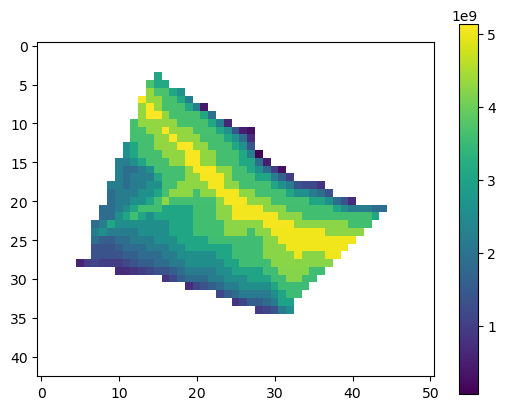

In [196]:
np.shape(volume_area)
c = plt.imshow(volume_area[2,:,:])
plt.colorbar(c)
plt.show()

In [206]:
len(tsnyb.time.dt.month)


11925

In [207]:
volume = np.nansum(np.nansum(volume_area,1),1)
volumedf = pn.DataFrame({'time': tsnyb.time,
                         'month': tsnyb.time.dt.month,
                         'year': tsnyb.time.dt.year,
                         'volume': volume})

In [208]:
volumedf

,time,month,year,volume
0,1993-01-01,1,1993,1.847170e+12
1,1993-02-01,2,1993,2.129455e+12
2,1993-03-01,3,1993,2.046361e+12
3,1993-04-01,4,1993,1.663096e+12
4,1993-05-01,5,1993,1.114638e+12
...,...,...,...,...
386,2025-03-01,3,2025,2.534362e+12
387,2025-04-01,4,2025,2.210286e+12
388,2025-05-01,5,2025,1.024784e+12
389,2025-06-01,6,2025,9.456991e+11


In [209]:
volumedf.to_csv('volumedf.csv')